In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu

from utils import FONT, FORMATTER

In [2]:
# ----------------------------------------------------------------------
# Smoothing windows (effective) per environment
# ----------------------------------------------------------------------
WINDOW_TAXI = 100
WINDOW_VSS  = 500
SIGMA_TAXI  = WINDOW_TAXI / 4    # = 25
SIGMA_VSS   = WINDOW_VSS  / 4    # = 62.5


# ----------------------------------------------------------------------
# Core helpers
# ----------------------------------------------------------------------
def smooth_curves(df, value_col, sigma):
    """
    Pivot a long-format dataframe to wide (rows=step, cols=seed),
    forward/backward-fill gaps, then apply a Gaussian filter to each
    seed's column independently.

    Returns
    -------
    index : pd.Index of step values
    smoothed : np.ndarray of shape (n_steps, n_seeds)
    """
    pivoted = df.pivot_table(index="_step", columns="seed", values=value_col)
    pivoted = pivoted.sort_index().ffill().bfill()
    arr = pivoted.values.astype(float)
    smoothed = np.empty_like(arr)
    for j in range(arr.shape[1]):
        smoothed[:, j] = gaussian_filter1d(arr[:, j], sigma=sigma)
    return pivoted.index, smoothed


def plot_panel(ax, configs, value_col, sigma, xlabel, ylabel, title,
               data_dir="/mnt/user-data/uploads"):
    """
    Render one panel: mean curves + per-seed min/max bands for each condition.

    `configs` is a list of (display_name, csv_basename, color) tuples.
    """
    for name, fname, color in configs:
        df = pd.read_csv(f"{data_dir}/{fname}.csv")
        idx, sm = smooth_curves(df, value_col, sigma=sigma)
        mean = sm.mean(axis=1)
        lo   = sm.min(axis=1)
        hi   = sm.max(axis=1)
        ax.plot(idx, mean, label=name, color=color, linewidth=2)
        ax.fill_between(idx, lo, hi, color=color, alpha=0.15)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_title(title)
    ax.legend(loc="lower right", prop=FONT)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

In [3]:
api = wandb.Api()
setups = {
    "TAXI" :{"obj": "ep_info/Objective", "name": "taxi_nominal"},
    "TAXI_ROBUST1" :{"obj": "ep_info/Objective", "name": "taxi_optimistic"},
    "TAXI_ROBUST2" :{"obj": "ep_info/Objective", "name": "taxi_pessimistic"},
    "VSS" :{"obj": "ep_info/Goal", "name": "vss_nominal"},
    "ROBUSTNESS_MOVE1" :{"obj": "ep_info/Goal", "name": "vss_move_minus25"},
    "ROBUSTNESS_MOVE2" :{"obj": "ep_info/Goal", "name": "vss_move_plus25"},
    "ROBUSTNESS_BALL1" :{"obj": "ep_info/Goal", "name": "vss_goal_plus25"},
    "ROBUSTNESS_BALL2" :{"obj": "ep_info/Goal", "name": "vss_goal_minus25"},
}

for env, setup in setups.items():
    runs = api.runs("goncamateus/DyLam", filters={"config.env": env, "config.setup": "Dylam"})

    dfs = []
    for run in runs:
        hist = run.history(keys=[setup["obj"], "_step"])
        hist["seed"] = run.config.get("seed", run.id)
        dfs.append(hist)

    pd.concat(dfs).to_csv(f"{setup['name']}.csv", index=False)

wandb: Currently logged in as: goncamateus to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Saved robustness_curves.pdf and robustness_curves.png.


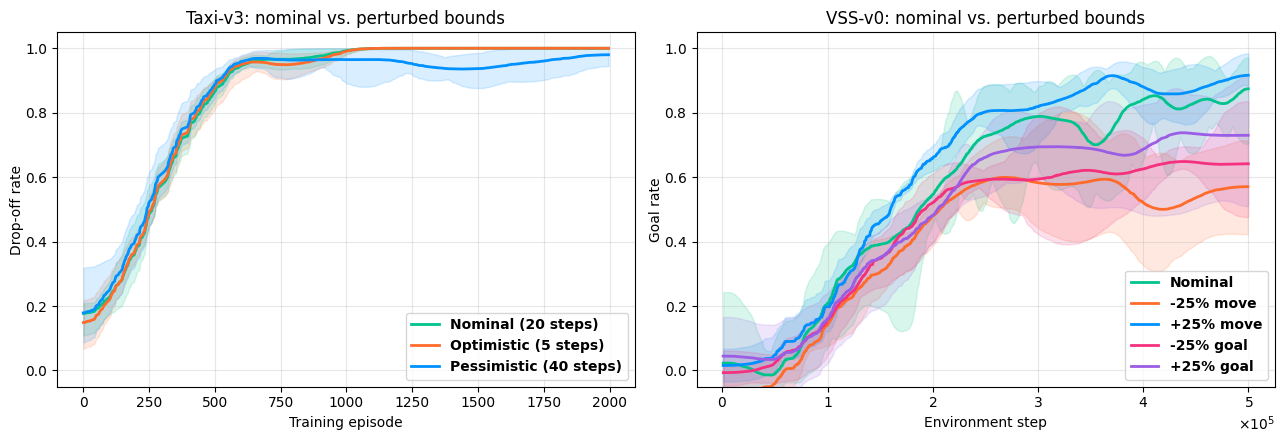

In [4]:
"""
Robustness curves for DyLam RQ3 experiments.

Per-environment Gaussian smoothing windows:
  - Taxi-v3: ~100-point window (sigma = 25)
  - VSS-v0:  ~250-point window (sigma = 62.5)

Convention: sigma = window / 4 so that ~95% of the kernel mass falls
within ±2σ ≈ `window` points. Per-seed smoothing is applied before
aggregation so that the min/max bands reflect actual seed variability,
not residual noise.

Expected CSV format (one file per condition):
    _step, ep_info/<metric>, seed
where each row is one logged datapoint and each seed contributes its
own time series.
"""


# ----------------------------------------------------------------------
# Build the two-panel robustness figure
# ----------------------------------------------------------------------
def main(
    out_pdf="robustness_curves.pdf", out_png="robustness_curves.png", data_dir="."
):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    plot_panel(
        axes[0],
        configs=[
            ("Nominal (20 steps)", "taxi_nominal", "#00C48C"),
            ("Optimistic (5 steps)", "taxi_optimistic", "#FF6B2B"),
            ("Pessimistic (40 steps)", "taxi_pessimistic", "#0091FF"),
        ],
        value_col="ep_info/Objective",
        sigma=SIGMA_TAXI,
        xlabel="Training episode",
        ylabel="Drop-off rate",
        title="Taxi-v3: nominal vs. perturbed bounds",
        data_dir=data_dir,
    )

    plot_panel(
        axes[1],
        configs=[
            ("Nominal", "vss_nominal", "#00C48C"),
            (r"-25% move", "vss_move_minus25", "#FF6B2B"),
            (r"+25% move", "vss_move_plus25", "#0091FF"),
            (r"-25% goal", "vss_goal_minus25", "#F5317F"),
            (r"+25% goal", "vss_goal_plus25", "#9B5DE5"),
        ],
        value_col="ep_info/Goal",
        sigma=SIGMA_VSS,
        xlabel="Environment step",
        ylabel="Goal rate",
        title="VSS-v0: nominal vs. perturbed bounds",
        data_dir=data_dir,
    )

    plt.tight_layout()
    plt.gca().yaxis.set_major_formatter(FORMATTER)
    plt.gca().xaxis.set_major_formatter(FORMATTER)
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.savefig(out_png, dpi=120, bbox_inches="tight")
    print(f"Saved {out_pdf} and {out_png}.")


if __name__ == "__main__":
    main()

In [5]:
LAST_FRAC = 0.10   # use the last 10% of each seed's episodes
 
TAXI_FILES = {
    "Nominal":     ("taxi_nominal.csv",     "ep_info/Objective"),
    "Optimistic":  ("taxi_optimistic.csv",  "ep_info/Objective"),
    "Pessimistic": ("taxi_pessimistic.csv", "ep_info/Objective"),
}
 
VSS_FILES = {
    "Nominal":             ("vss_nominal.csv",       "ep_info/Goal"),
    "Ball-approach -25%":  ("vss_move_minus25.csv",  "ep_info/Goal"),
    "Ball-approach +25%":  ("vss_move_plus25.csv",   "ep_info/Goal"),
    "Ball-to-goal  -25%":  ("vss_goal_minus25.csv",  "ep_info/Goal"),
    "Ball-to-goal  +25%":  ("vss_goal_plus25.csv",   "ep_info/Goal"),
}

In [6]:
def per_seed_summary(path, metric_col, last_frac=LAST_FRAC):
    """
    Load CSV, compute the mean of the final last_frac of episodes
    for each seed, return array of shape (n_seeds,).
    """
    df = pd.read_csv(path)
    summaries = []
    for seed, grp in df.groupby("seed"):
        grp = grp.sort_values("_step")
        cutoff = int(len(grp) * (1 - last_frac))
        summaries.append(grp.iloc[cutoff:][metric_col].mean())
    return np.array(summaries)
 
 
def run_group(label, files_dict, nominal_key="Nominal"):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  {'Condition':<25} {'n':>3}  {'mean':>7}  {'std':>7}  "
          f"{'U':>7}  {'p':>8}  sig")
    print(f"  {'-'*60}")
 
    # Load all conditions
    arrays = {}
    for cond, (path, metric) in files_dict.items():
        arrays[cond] = per_seed_summary(path, metric)
 
    ref = arrays[nominal_key]
 
    for cond, arr in arrays.items():
        n  = len(arr)
        mu = arr.mean()
        sd = arr.std(ddof=1)
 
        if cond == nominal_key:
            print(f"  {cond:<25} {n:>3}  {mu:>7.4f}  {sd:>7.4f}  "
                  f"{'---':>7}  {'---':>8}  [reference]")
            continue
 
        U, p = mannwhitneyu(ref, arr, alternative="two-sided")
        direction = "nom > pert" if ref.mean() > arr.mean() else "nom < pert"
        sig = "*" if p < 0.05 else "n.s."
        print(f"  {cond:<25} {n:>3}  {mu:>7.4f}  {sd:>7.4f}  "
              f"{U:>7.0f}  {p:>8.4f}  {sig}  ({direction})")
 
    return arrays
 
  
def latex_row(cond, arr, ref=None, dagger=False):
    """Return a single LaTeX table row."""
    n  = len(arr)
    mu = arr.mean()
    sd = arr.std(ddof=1)
    if ref is None:
        return (f"    & {cond:<30} & ${mu:.3f} \\pm {sd:.3f}$ "
                f"& ---  & ---            \\\\")
    U, p = mannwhitneyu(ref, arr, alternative="two-sided")
    sig = r"^{\ast}" if p < 0.05 else ""
    dag = r"^{\dagger}" if dagger and 0.05 <= p < 0.10 else ""
    return (f"    & {cond:<30} & ${mu:.3f} \\pm {sd:.3f}$ "
            f"& ${U:.0f}$ & ${p:.3f}{sig}{dag}$ \\\\")

In [7]:
taxi = run_group("Taxi-v3", TAXI_FILES)
vss  = run_group("VSS-v0",  VSS_FILES)

print("\n\n" + "="*60)
print("  LaTeX rows (paste into table)")
print("="*60)

ref_taxi = taxi["Nominal"]
ref_vss  = vss["Nominal"]

print("\n% --- Taxi ---")
for cond, arr in taxi.items():
    ref = None if cond == "Nominal" else ref_taxi
    print(latex_row(cond, arr, ref))

print("\n% --- VSS ---")
for cond, arr in vss.items():
    ref = None if cond == "Nominal" else ref_vss
    # flag move+25 as potentially marginal
    dagger = (cond == "Ball-approach +25%")
    print(latex_row(cond, arr, ref, dagger=dagger))


  Taxi-v3
  Condition                   n     mean      std        U         p  sig
  ------------------------------------------------------------
  Nominal                    10   1.0000   0.0000      ---       ---  [reference]
  Optimistic                 10   1.0000   0.0000       50    1.0000  n.s.  (nom < pert)
  Pessimistic                10   0.9780   0.0274       75    0.0146  *  (nom > pert)

  VSS-v0
  Condition                   n     mean      std        U         p  sig
  ------------------------------------------------------------
  Nominal                    10   0.8300   0.0634      ---       ---  [reference]
  Ball-approach -25%          5   0.5680   0.0701       50    0.0026  *  (nom > pert)
  Ball-approach +25%          5   0.9040   0.0498        8    0.0480  *  (nom < pert)
  Ball-to-goal  -25%          5   0.6440   0.1260       46    0.0097  *  (nom > pert)
  Ball-to-goal  +25%          5   0.6760   0.1081       46    0.0137  *  (nom > pert)


  LaTeX rows (paste 